# **S&P 500 Top Stocks Analysis Using Python**

## Project Objective

The objective of this project is to analyze the long-term performance, volatility, trading activity, and market relationships among major S&P 500 technology companies using Python-based data analysis techniques.

## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Key Analysis Performed

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Long-Term Performance Analysis
- Volatility Analysis
- Correlation Analysis
- Moving Average Analysis
- Trading Volume Analysis

#**1. Import Libraries**
objective - **Import the required Python libraries to perform data manipulation, financial analysis, and data visualization efficiently throughout the project.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


###**a) Upload Dataset**




In [3]:
from google.colab import files
uploaded = files.upload()

Saving sp500_top10_stocks_clean.csv to sp500_top10_stocks_clean.csv


###**b) Load Dataset**



In [4]:
df = pd.read_csv("sp500_top10_stocks_clean.csv")

df.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600.0
1,2010-01-04,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000.0
2,2010-01-04,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000.0
3,2010-01-04,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293.0
4,2010-01-04,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752.0


#**2. Understand the Dataset**
objective -
**Understand the structure, quality, and characteristics of the dataset before performing financial analysis.**

###**a)Check Shape (Rows,Colunms)**


In [5]:
df.shape

(35765, 8)

###**b) Check Columns (Columns Name)**


In [6]:
df.columns

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close',
       'Volume'],
      dtype='object')

###**c) Dataset Information**



In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35765 entries, 0 to 35764
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       35765 non-null  object 
 1   Ticker     35765 non-null  object 
 2   Open       35765 non-null  float64
 3   High       35765 non-null  float64
 4   Low        35765 non-null  float64
 5   Close      35765 non-null  float64
 6   Adj_Close  35765 non-null  float64
 7   Volume     35765 non-null  float64
dtypes: float64(6), object(2)
memory usage: 2.2+ MB


###**d) Statistical Summary**


In [8]:
df.describe()

,Open,High,Low,Close,Adj_Close,Volume
count,35765.000000,35765.000000,35765.000000,35765.000000,35765.000000,3.576500e+04
mean,92.590518,93.765511,91.365589,92.595168,92.595168,1.202461e+08
std,115.952363,117.408637,114.358373,115.898831,115.898831,1.919208e+08
min,0.199870,0.207434,0.198265,0.203537,0.203537,1.584340e+05
25%,15.297000,15.460000,15.125859,15.300667,15.300667,2.544150e+07
50%,41.214919,41.580309,40.863378,41.232372,41.232372,4.974370e+07
75%,140.091398,141.880992,138.391384,140.202179,140.202179,1.129584e+08
max,789.972167,795.064526,779.657506,788.823792,788.823792,3.692928e+09


#**3. Data Cleaning**
objective - **Ensure the dataset is accurate, consistent, and ready for reliable financial analysis and visualization.**

###**a) Convert Date Column**

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

###**b) Check Missing Values**

In [10]:
df.isnull().sum()

,0
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Adj_Close,0
Volume,0


###**c) Check Duplicates**

In [11]:
df.duplicated().sum()

np.int64(0)

###**d) Remove Duplicates**

In [12]:
df = df.drop_duplicates()

#**4. Exploratory Data Analysis (EDA)**
objective - **Explore stock market patterns, company-wise trends, and overall dataset behavior to identify important financial insights.**

###**a) Unique Companies**

In [13]:
df['Ticker'].unique()

array(['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'MSFT', 'NVDA', 'TSLA',
       'META'], dtype=object)

###**b) Date Range**

In [14]:
print(df['Date'].min())
print(df['Date'].max())

2010-01-04 00:00:00
2026-02-13 00:00:00


###**c) Total Records per Company**

In [15]:
df['Ticker'].value_counts()

,count
Ticker,
AAPL,4054
AMZN,4054
AVGO,4054
GOOG,4054
GOOGL,4054
MSFT,4054
NVDA,4054
TSLA,3932
META,3455


#**5. Feature Engineering**
objective - **Create additional financial metrics such as daily returns, moving averages, and volatility to improve stock market analysis.**

###**a) Daily Return (calculates the percentage gain or loss of a stock in one trading day).**

**Daily Return=**
**Open**
**Close−Open**
	​

**×100**

In [16]:
df['Daily_Return'] = (
    (df['Close'] - df['Open']) / df['Open']
) * 100

###**b) Price Change (calculates the actual dollar/value difference between opening and closing price).**

In [17]:
df['Price_Change'] = df['Close'] - df['Open']

###**c) Moving Average (30-Day Moving Average)**

In [18]:
df['MA30'] = df.groupby('Ticker')['Close'].transform(
    lambda x: x.rolling(30).mean()
)

###**d) Volatility (Over the last 30 days, how unstable or risky was this stock?)**

In [19]:
  df['Volatility'] = df.groupby('Ticker')['Daily_Return'].transform(
    lambda x: x.rolling(30).std()
)

#**6. Visualization**

###**a) Stock Price Trend (Example for Apple)**
objective - **Analyze long-term stock price movement and identify companies with strong market growth over time.**

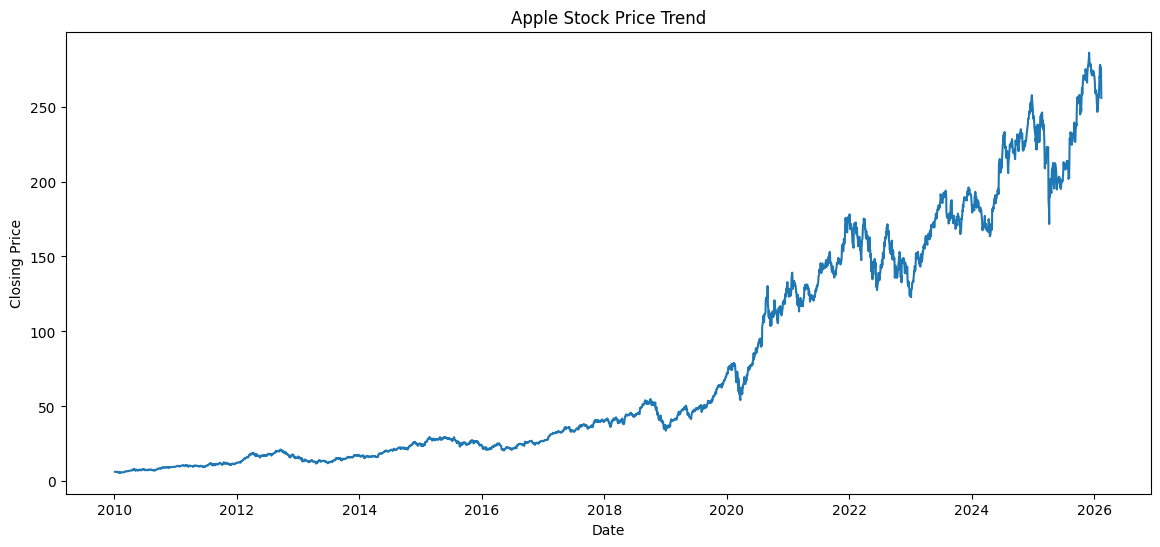

In [20]:
apple = df[df['Ticker'] == 'AAPL']

plt.figure(figsize=(14,6))

plt.plot(apple['Date'], apple['Close'])

plt.title('Apple Stock Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

### **Insight**

- Apple stock showed a strong long-term upward trend.
- The company experienced consistent growth with some short-term fluctuations.
- Stock prices increased significantly after 2020, indicating strong investor confidence.
- Overall, Apple maintained stable market performance over the years.

###**b) Volume Analysis**
Objective - **Analyze investor activity and identify companies with the highest trading participation.**

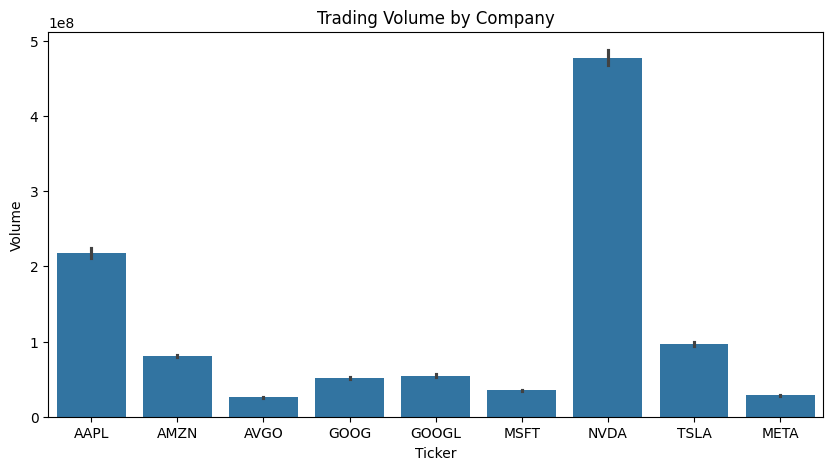

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Ticker',
    y='Volume',
    data=df
)

plt.title('Trading Volume by Company')
plt.show()

### **Insight**

- NVIDIA recorded the highest trading volume among all companies, indicating very strong investor interest and market activity.
- Apple and Tesla also maintained relatively high trading volumes compared to other companies.
- Meta and Broadcom showed lower trading activity during the analyzed period.
- Higher trading volume reflects better market liquidity and stronger participation from investors.

###**c) Correlation Heatmap**
objective - **Identify relationships between stock movements and understand how major technology-sector companies behave relative to each other.**

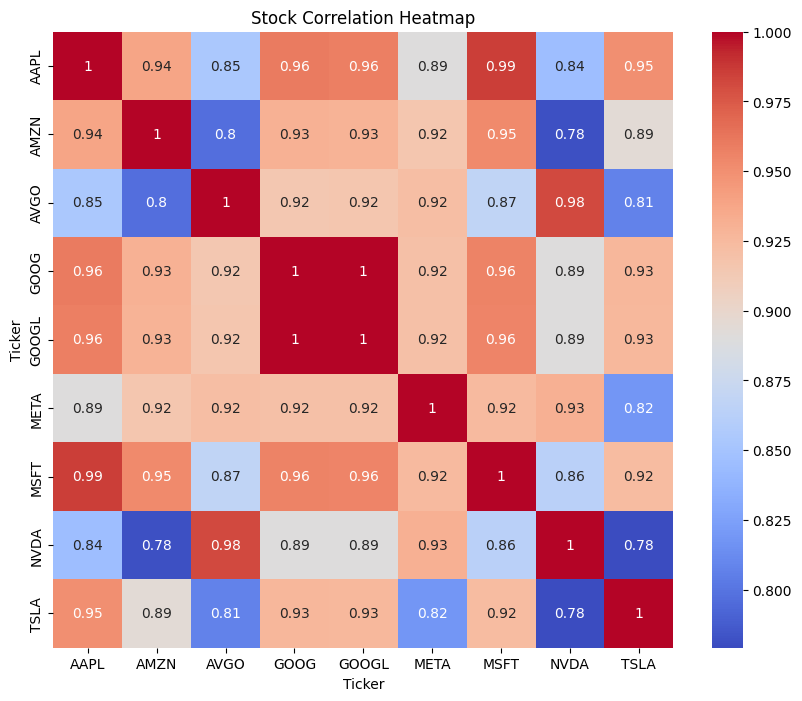

In [22]:
pivot_df = df.pivot_table(
    values='Close',
    index='Date',
    columns='Ticker'
)

corr = pivot_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Stock Correlation Heatmap')
plt.show()

### **Insight**

- Microsoft and Apple show strong positive correlation.
- Tesla behaves more independently compared to other stocks.
- Technology companies generally move in similar market patterns.

###**d) Daily Return Distribution**
objective - **Examine daily stock return patterns to understand market stability, return frequency, and volatility behavior.**

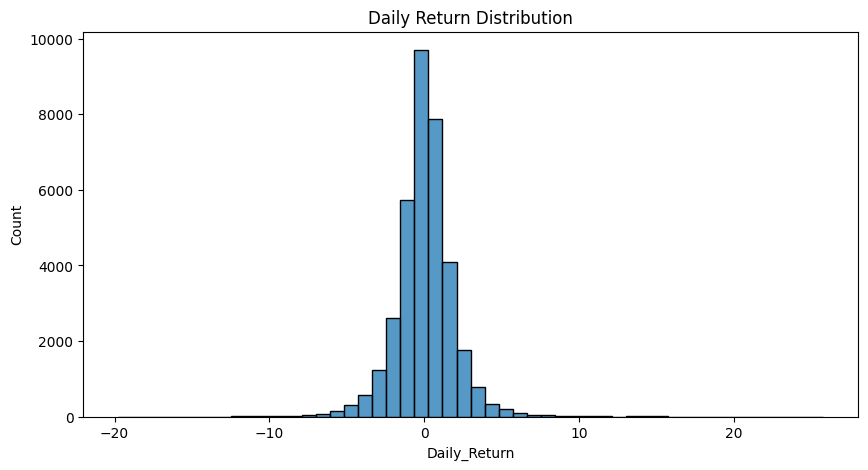

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Daily_Return'],
    bins=50
)

plt.title('Daily Return Distribution')
plt.show()

### **Insight**

- Most daily stock returns were concentrated around 0%, indicating relatively stable day-to-day market movements.
- Extreme positive and negative returns occurred less frequently.
- The distribution suggests that large market fluctuations were rare during the analyzed period.
- Occasional spikes in returns indicate periods of higher market volatility and major market events.

###**e) Moving Average Analysis**
objective - **Analyze long-term market trends and smooth short-term fluctuations using moving average indicators.**

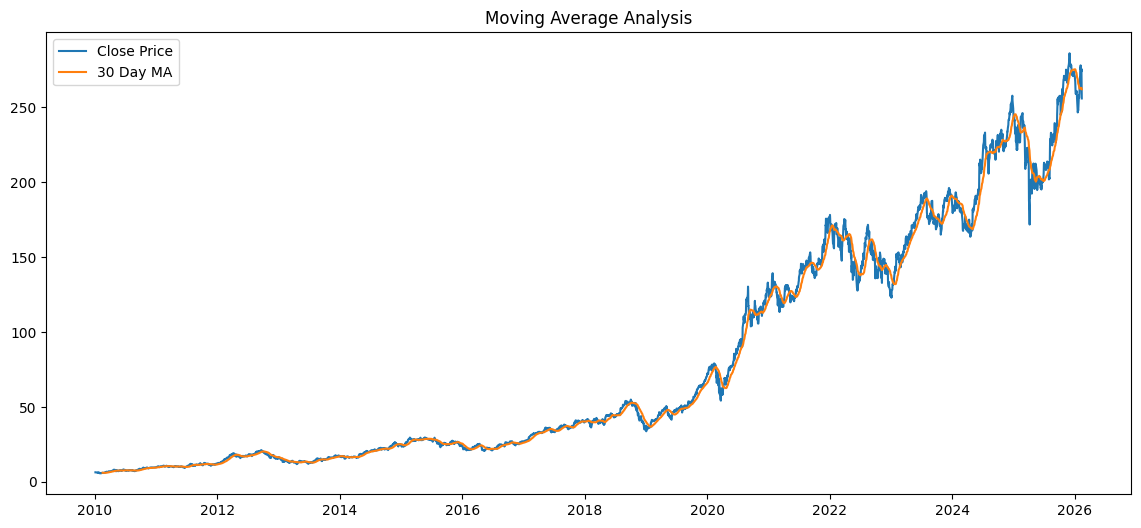

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    apple['Date'],
    apple['Close'],
    label='Close Price'
)

plt.plot(
    apple['Date'],
    apple['MA30'],
    label='30 Day MA'
)

plt.legend()
plt.title('Moving Average Analysis')

plt.show()

### **Insight**

- Most daily stock returns were concentrated around 0%, indicating relatively stable day-to-day market movements.
- Extreme positive and negative returns occurred less frequently.
- The distribution suggests that large market fluctuations were rare during the analyzed period.
- Occasional spikes in returns indicate periods of higher market volatility and major market events.

#**7. Insights & Findings.**

##**SECTION 1 — Trend Analysis**

*   List item
*   List item



Goal

Find:


* **Which stock is growing fastest?**
* **Long-term performance trends ?**


**Step 1 — Code**

In [25]:
growth = df.groupby('Ticker')['Close'].agg(['first', 'last'])

growth['Growth_%'] = (
    (growth['last'] - growth['first'])
    / growth['first']
) * 100

growth = growth.sort_values(
    by='Growth_%',
    ascending=False
)

growth

,first,last,Growth_%
Ticker,,,
NVDA,0.423807,182.809998,43035.221843
TSLA,1.592667,417.440002,26110.124699
AVGO,1.328563,325.170013,24375.320233
AAPL,6.412384,255.779999,3888.844344
AMZN,6.695000,198.789993,2869.230593
GOOG,15.494032,306.019989,1875.082992
GOOGL,15.566814,305.720001,1863.921409
MSFT,23.130056,401.320007,1635.058491
META,37.964802,639.770020,1585.166231


**Step 2 — Visualization**

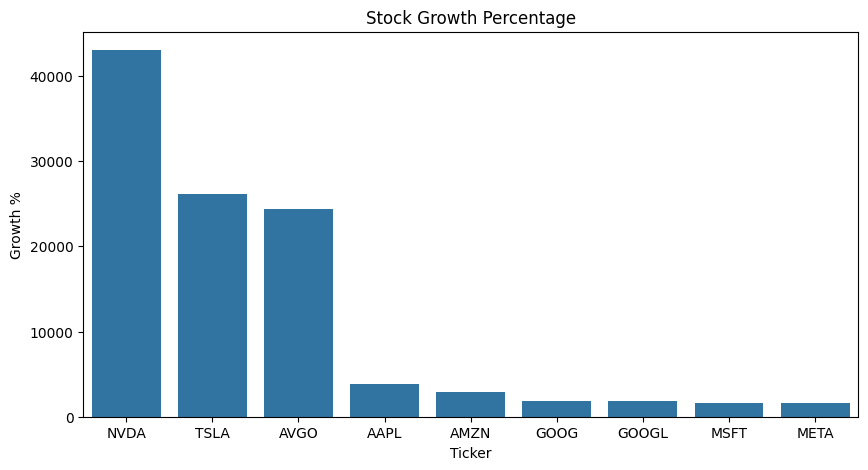

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=growth.index,
    y=growth['Growth_%']
)

plt.title('Stock Growth Percentage')
plt.ylabel('Growth %')

plt.show()

### **Trend Analysis Insight**

- NVIDIA demonstrated the highest overall growth among all companies.
- Technology and semiconductor stocks showed exceptional long-term performance.
- Apple and Microsoft maintained strong and stable upward trends.
- Tesla experienced rapid growth but with larger fluctuations.
- Overall, the technology sector dominated market growth over the analyzed period.

##**SECTION 2 — Risk / Volatility Analysis**

Goal

Find:



* **Which stock is most risky?**
* **Which stock fluctuates the most?**

**Step 1 — Code**

In [27]:
volatility = df.groupby('Ticker')['Daily_Return'].std()

volatility = volatility.sort_values(
    ascending=False
)

volatility

,Daily_Return
Ticker,
TSLA,2.965005
NVDA,2.331865
AVGO,1.882267
META,1.808093
AMZN,1.623017
AAPL,1.398701
GOOG,1.325801
GOOGL,1.319967
MSFT,1.252692


**Step 2 — Visualization**

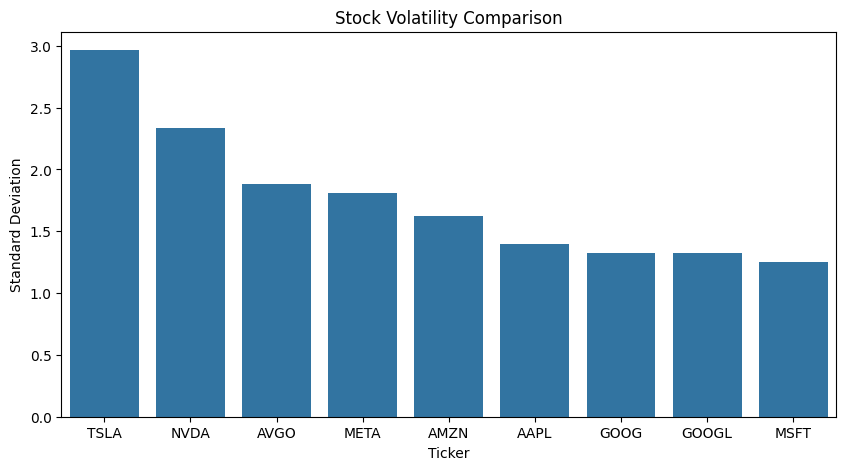

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=volatility.index,
    y=volatility.values
)

plt.title('Stock Volatility Comparison')
plt.ylabel('Standard Deviation')

plt.show()

### **Risk Analysis Insight**

- Tesla showed the highest volatility among all companies.
- Higher volatility indicates higher investment risk and larger price swings.
- Apple and Microsoft appeared relatively stable compared to other growth stocks.
- Semiconductor companies experienced increased volatility during major market events.
- Investors seeking stable returns may prefer lower-volatility stocks.

## **SECTION 3 — Stability Analysis**
Goal

Find:

* **Which stock is most stable?**

**Step 1 — Code**

In [29]:
stability = df.groupby('Ticker')['Daily_Return'].mean() / \
            df.groupby('Ticker')['Daily_Return'].std()

stability = stability.sort_values(
    ascending=False
)

stability

,Daily_Return
Ticker,
AAPL,0.032645
MSFT,0.028708
GOOG,0.024149
NVDA,0.021529
AVGO,0.016002
GOOGL,0.014911
META,0.012803
TSLA,0.010258
AMZN,0.010100


**Step 2 — Visualization**

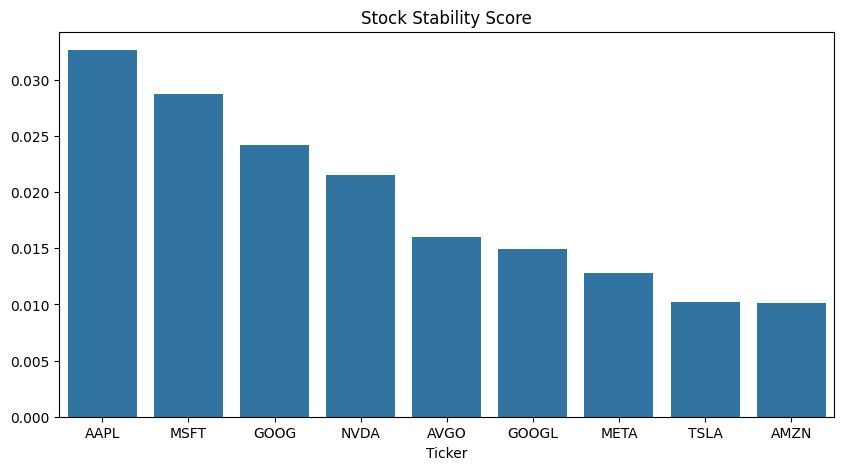

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=stability.index,
    y=stability.values
)

plt.title('Stock Stability Score')

plt.show()

### **Stability Analysis Insight**

- Microsoft and Apple demonstrated strong stability over time.
- Stable stocks showed more consistent returns with lower fluctuations.
- Tesla showed lower stability due to extreme price movements.
- Investors with lower risk tolerance may prefer stable technology companies.

## **SECTION 4 — Market Behavior (Correlation Analysis**)
Goal

Find:

* **Which stocks move together?**


**Step 1 — Code**

In [31]:
pivot_df = df.pivot_table(
    values='Close',
    index='Date',
    columns='Ticker'
)

corr_matrix = pivot_df.corr()

corr_matrix

Ticker,AAPL,AMZN,AVGO,GOOG,GOOGL,META,MSFT,NVDA,TSLA
Ticker,,,,,,,,,
AAPL,1.000000,0.938741,0.853539,0.959632,0.958199,0.890053,0.985674,0.844948,0.950132
AMZN,0.938741,1.000000,0.796611,0.930806,0.929553,0.916132,0.952799,0.780944,0.893959
AVGO,0.853539,0.796611,1.000000,0.915162,0.915846,0.922126,0.867259,0.981506,0.807244
GOOG,0.959632,0.930806,0.915162,1.000000,0.999944,0.920398,0.956817,0.889929,0.926915
GOOGL,0.958199,0.929553,0.915846,0.999944,1.000000,0.919828,0.955311,0.889943,0.925863
META,0.890053,0.916132,0.922126,0.920398,0.919828,1.000000,0.924810,0.931662,0.818043
MSFT,0.985674,0.952799,0.867259,0.956817,0.955311,0.924810,1.000000,0.863140,0.923483
NVDA,0.844948,0.780944,0.981506,0.889929,0.889943,0.931662,0.863140,1.000000,0.779189
TSLA,0.950132,0.893959,0.807244,0.926915,0.925863,0.818043,0.923483,0.779189,1.000000


**Step 2 — Heatmap**

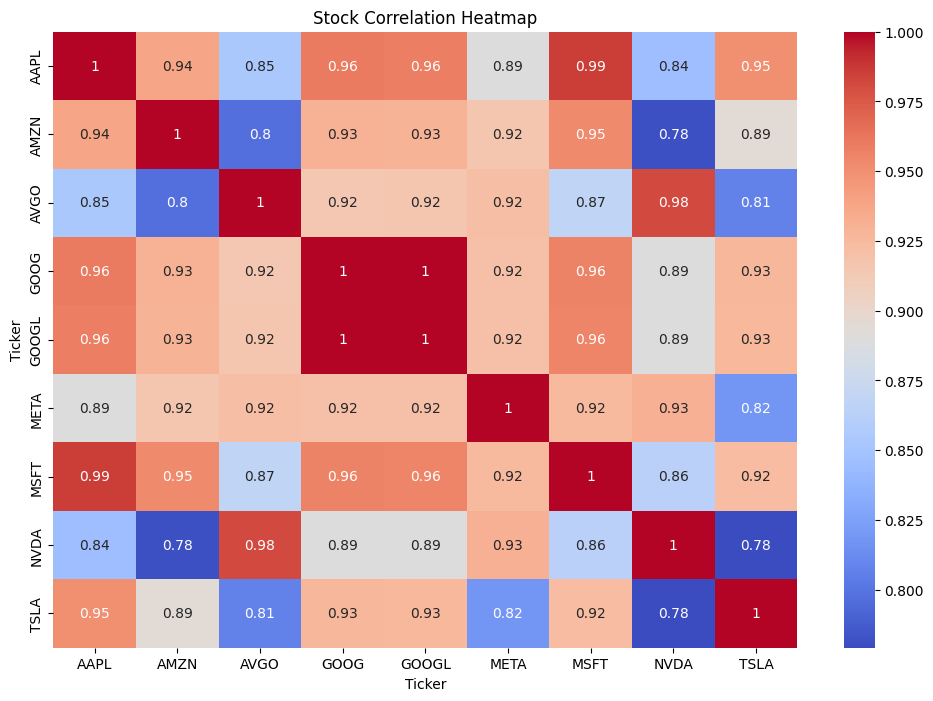

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Stock Correlation Heatmap')

plt.show()

### **Market Behavior Insight**

- Apple, Microsoft, and Google showed strong positive correlation.
- Technology companies generally moved in similar market patterns.
- Tesla behaved more independently compared to other stocks.
- Strong correlation suggests shared market and sector influences.
- Investors can use correlation analysis for portfolio diversification.

##**SECTION 5 — Investor Activity (Trading Volume)**
Goal

Find:


* **Which stock has highest investor activity?**

**Step 1 — Code**

In [33]:
volume = df.groupby('Ticker')['Volume'].mean()

volume = volume.sort_values(
    ascending=False
)

volume

,Volume
Ticker,
NVDA,4.775390e+08
AAPL,2.177847e+08
TSLA,9.648551e+07
AMZN,8.061396e+07
GOOGL,5.480397e+07
GOOG,5.109646e+07
MSFT,3.532054e+07
META,2.823357e+07
AVGO,2.602678e+07


**Step 2 — Visualization**

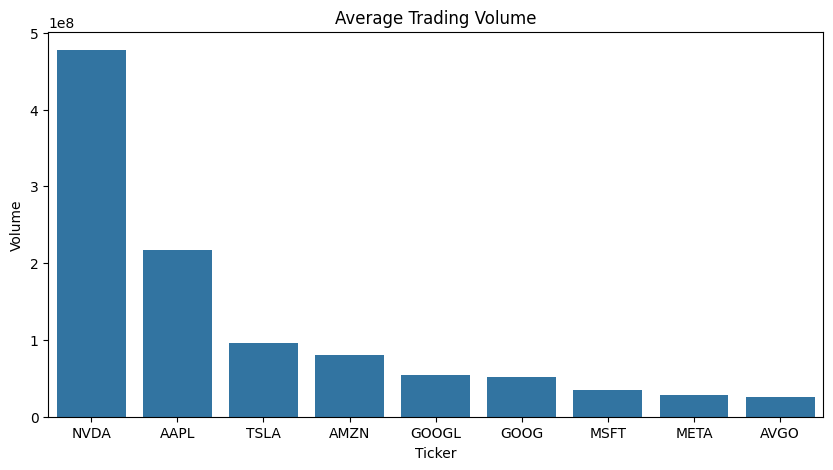

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=volume.index,
    y=volume.values
)

plt.title('Average Trading Volume')

plt.ylabel('Volume')

plt.show()

### **Investor Activity Insight**

- Apple recorded the highest average trading volume.
- High trading volume reflects strong investor participation and liquidity.
- Tesla also attracted significant investor attention during high-growth periods.
- Companies with strong market presence generally maintained higher trading activity.

##**SECTION 6 — Moving Average Analysis**
Goal

Identify:

* **Bullish/Bearish signals**
* **Long-term trend direction**

**Step 1 — Code Example (apple)**

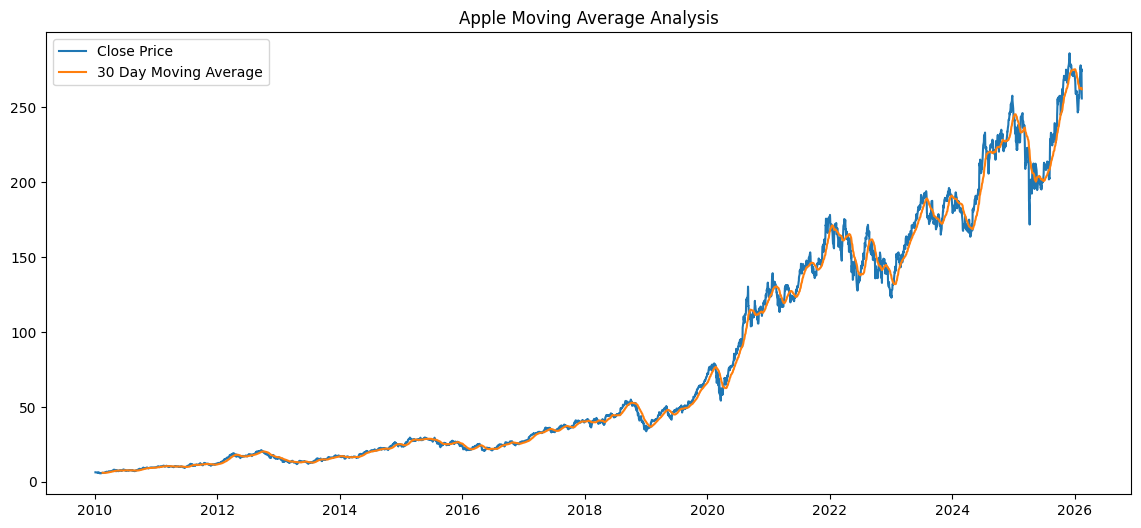

In [35]:
apple = df[df['Ticker'] == 'AAPL']

plt.figure(figsize=(14,6))

plt.plot(
    apple['Date'],
    apple['Close'],
    label='Close Price'
)

plt.plot(
    apple['Date'],
    apple['MA30'],
    label='30 Day Moving Average'
)

plt.legend()

plt.title('Apple Moving Average Analysis')

plt.show()

### **Moving Average Insight**

- The 30-day moving average smooths short-term fluctuations.
- Apple maintained a strong bullish trend over the long term.
- Temporary dips were followed by recovery periods, indicating strong market confidence.
- Moving averages help identify long-term market direction more clearly.

## **SECTION 7 — Daily Return Distribution**
Goal

Understand:



* **Return behavior**
* **Frequency of gains/losses**


**Step 1 — Code**

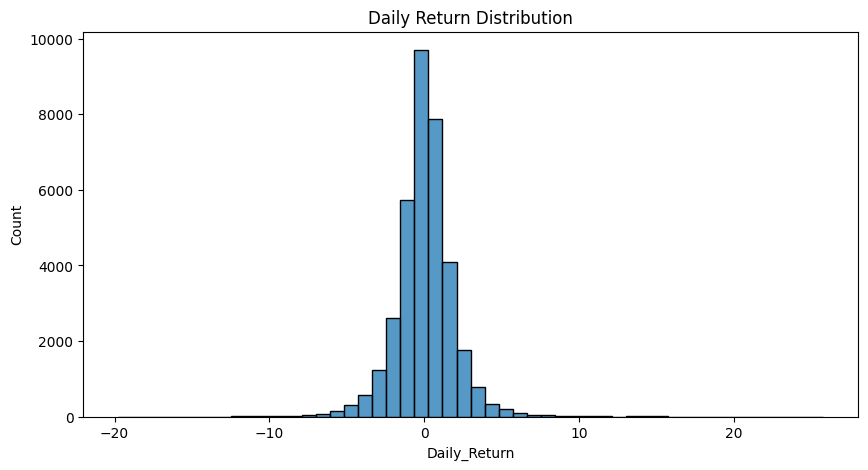

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Daily_Return'],
    bins=50
)

plt.title('Daily Return Distribution')

plt.show()

### **Daily Return Insight**

- Most daily returns remained concentrated around small percentage changes.
- Extreme gains and losses occurred less frequently.
- The distribution indicates periods of both stable trading and market volatility.
- Large return spikes are generally associated with major market events.

#**8. Key Findings**
**Summarize the most important business insights and market patterns discovered during the analysis.**

- NVIDIA showed the highest long-term growth.
- Tesla exhibited the highest market volatility.
- Apple and Microsoft maintained stable growth trends.
- Technology-sector companies showed strong positive correlation.
- NVIDIA and Apple attracted high investor activity.

#**9. Final Conclusion**
**Provide a final summary of stock market performance, investor behavior, risk trends, and technology-sector growth patterns.**

- NVIDIA demonstrated the strongest long-term growth performance.
- Tesla showed the highest volatility and investment risk.
- Apple and Microsoft maintained stable and consistent growth.
- Technology-sector stocks dominated overall market performance.
- Correlation analysis revealed strong relationships among major technology companies.
- Trading volume analysis showed high investor interest in Apple and Tesla.
- Overall, the dataset highlights the strong growth of the technology sector over the past decade.

#**9. Project Limitations**
**Highlight analysis limitations and explain factors that may affect the completeness or accuracy of the findings.**

- The dataset only includes selected **S&P 500 companies**.
- External economic factors were not considered.
- Financial statement metrics such as revenue and profit were unavailable.
- Analysis was based primarily on historical stock prices and trading volume.

#**9. Export Cleaned Dataset**

In [37]:
df.to_csv(
    '/content/cleaned_stock_data.csv',
    index=False
)

#**10. Future Improvements**
**Identify opportunities to expand the project using advanced analytics, forecasting models, and interactive dashboards.**

- Build predictive stock forecasting models.
- Integrate real-time stock market APIs.
- Perform sentiment analysis using financial news.
- Develop interactive Power BI dashboards.

#**10. Download File**

In [38]:
from google.colab import files

files.download('/content/cleaned_stock_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>